## 4.1 Fourier Optics Examples in python

###  Example 1 : difference between Fast Fourier Transform (FFT) and Discrete Fourier Transform (DFT)

#### DFT vs FFT: A Practical Comparison

This notebook compares the **Discrete Fourier Transform (DFT)** and the **Fast Fourier Transform (FFT)**.  
Both produce identical numerical results, but their computational efficiency differs dramatically.

##### Theory

For a sequence $g[n]$ of length $N$, the DFT is defined as  

$$
G[k] = \sum_{n=0}^{N-1} g[n] \, e^{-i 2\pi k n / N}, \qquad k = 0,\dots,N-1
$$

A direct implementation uses two nested loops, requiring $O(N^2)$ operations.  
The FFT is a family of algorithms that compute the **same** DFT in $O(N \log N)$ operations by exploiting symmetries and periodicities of the complex exponentials.

For large $N$ (e.g., $N=1064$), the difference in speed is enormous – the FFT completes in milliseconds, while a manual DFT may take minutes or hours.

##### What this code does

1. **Creates a shifted input signal**  
   The original Gaussian $g(x) = \exp[-(x/w_0)^2]$ (with $w_0 = 0.2$) is circularly shifted by $N/2$ using two manual loops. This shift is kept for illustration; the comparison works for any input.

2. **Implements a manual DFT** (double loop) – intentionally slow, for educational purposes.

3. **Computes the FFT** using `np.fft.fft` – fast, production‑ready.

4. **Compares execution times** with Python’s `time` module, showing the huge speed advantage of the FFT.

5. **Verifies numerical equivalence** – the two outputs match up to floating‑point precision.

6. **Plots magnitude and phase** of both transforms, confirming they are identical.

##### Why this is helpful

- **Understanding the cost of a naive DFT** – you will see that an $O(N^2)$ algorithm becomes unusable for realistic data sizes.
- **Appreciating why libraries use FFT** – in Fourier optics, images are often $1024 \times 1024$ or larger; an FFT is essential.
- **Recognising that the FFT is not an approximation** – it is an exact re‑implementation of the DFT.
- **Learning to use timing as a tool** for comparing algorithm performance.

For any real Fourier optics simulation, always use `numpy.fft` (or `scipy.fft`). The manual DFT shown here is purely for illustration.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time


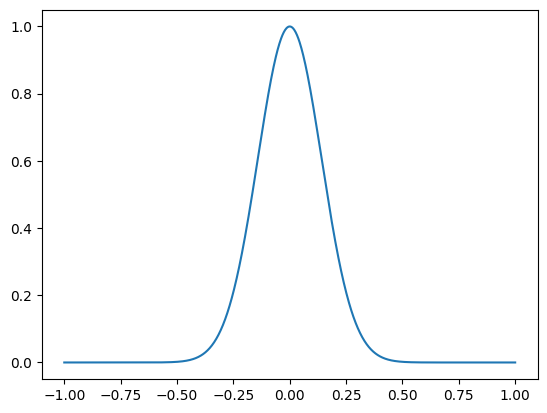

In [3]:
N = 1024
x0 = np.linspace(-1, 1, N)
delta = x0[1] - x0[0]
w0 = 2e-1
gx = lambda x : np.exp(-(x / w0)**2)
gx = gx(x0)
plt.plot(x0, gx)


In [4]:
np2 = [x for x in range(0, int(N))]

In [5]:
gxp = []

for i in range(0, int(N/2)):
    # print(int((i + N/2)))
    gxp.append(gx[int((i + N/2))])

for i in range(0, int(N/2)):
    # print(int((i)))
    gxp.append(gx[int(i)])


In [6]:
len(gxp) == len(gx) == N

True

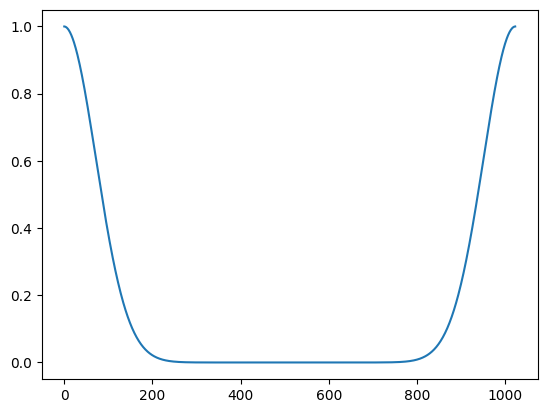

In [7]:
plt.plot(np2, gxp)

In [8]:
Gm = np.zeros(N, dtype=complex)
start_t = time.time()
for k in range(N):                  
    s = 0 + 0j
    for n in range(N):              
        s += gxp[n] * np.exp(-2j * np.pi * k * n / N)
    Gm[k] = s

end_t = time.time()
time_manual = end_t - start_t
print(f"Manual DFT completed in {time_manual:.2f} seconds")

Manual DFT completed in 1.97 seconds


Starting NumPy FFT...
NumPy FFT completed in 0.061162 seconds
Time difference between manual DFT and FFT: 1.9074079990386963 seconds
Max difference between manual DFT and FFT: 5.47e-11


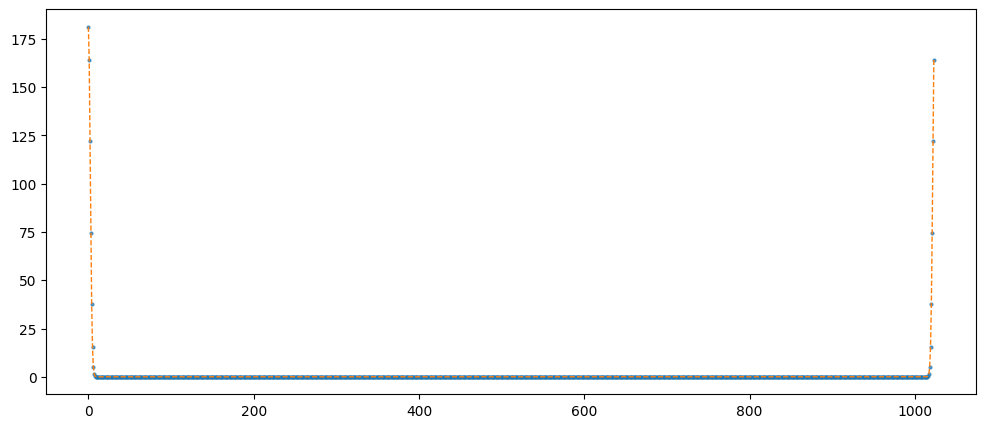

C:\Users\MOBIT\AppData\Local\Temp\ipykernel_5264\3007832109.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


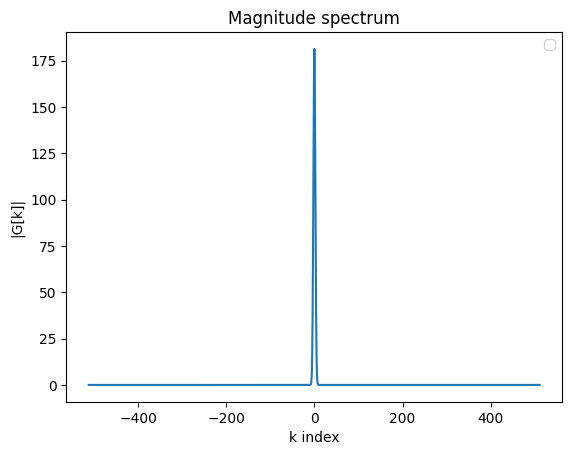

In [9]:
# -------------------  FFT  -------------------

print("Starting NumPy FFT...")
start_fft = time.time()
G_fft = np.fft.fft(gxp)          # FFT of the same shifted signal


end_fft = time.time()
time_fft = end_fft - start_fft
print(f"NumPy FFT completed in {time_fft:.6f} seconds")

# difference of the times
print(f"Time difference between manual DFT and FFT: {time_manual - time_fft} seconds")

# difference of the values
diff = np.max(np.abs(Gm - G_fft))
print(f"Max difference between manual DFT and FFT: {diff:.2e}")

# ------------------- Plot comparison -------------------
plt.figure(3, figsize=(12, 5))

plt.plot(np.abs(Gm), 'o', label='Manual DFT', markersize=2, alpha=0.7)
plt.plot(np.abs(G_fft), '--', label='NumPy FFT', linewidth=1)
plt.show()
plt.title('Magnitude spectrum')
plt.xlabel('k index')
plt.ylabel('|G[k]|')
plt.legend()
Gm_shifted = np.concatenate((Gm[N//2:], Gm[:N//2]))
k_shifted = np.arange(-N//2, N//2)
plt.plot(k_shifted, np.abs(Gm_shifted))
plt.show()


In [10]:
# <!-- Starting NumPy FFT...
# NumPy FFT completed in 0.000000 seconds
# Time difference between manual DFT and FFT: 1.4666252136230469
# Max difference between manual DFT and FFT: 4.67e-11 -->
# -------------------------------------------------------
# Starting NumPy FFT...
# NumPy FFT completed in 0.002990 seconds
# Time difference between manual DFT and FFT: 88.73701930046082 seconds
# Max difference between manual DFT and FFT: 1.98e-09

##  FFT -- Examples

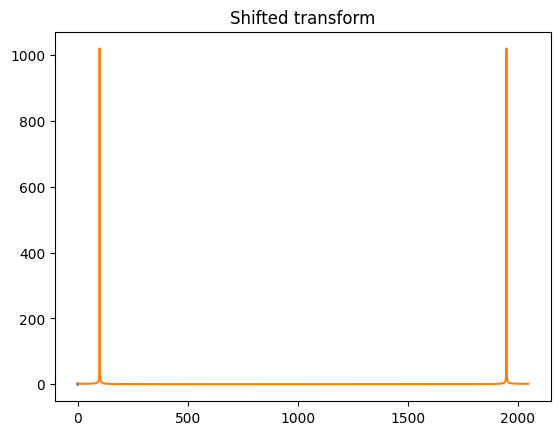

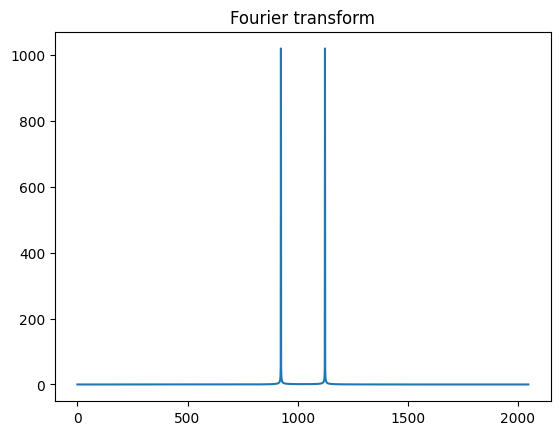

c:\Users\MOBIT\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\MOBIT\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


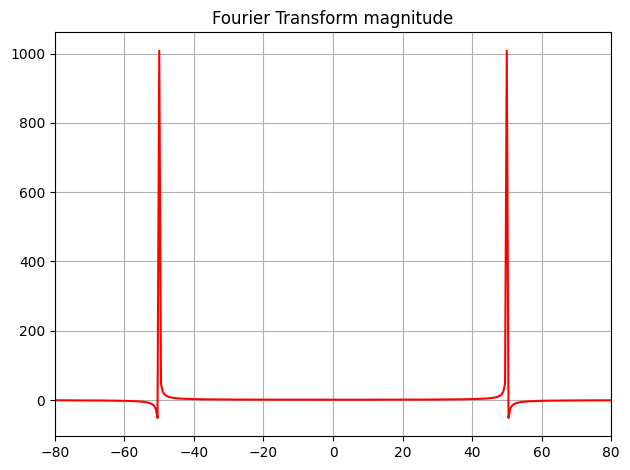

In [11]:
N = 2048
x_min, x_max = -1, 1
x = np.linspace(-1, 1, N)
dx = x[1] - x[0] # delta 
f = 50
s = np.cos(2*np.pi*f*x) # function
plt.plot(x, s)
S = np.fft.fft(s) # Fourier transform
plt.plot(np.abs(S))
plt.title("Shifted transform")
plt.show()

S = np.fft.fftshift(S) # Fourier transform shift
plt.plot(np.abs(S))
plt.title("Fourier transform")
plt.show()


freq = np.fft.fftfreq(N, d=dx)        # Fourier transform in frequency domain
freq_centered = np.fft.fftshift(freq)  # Shift fourier frequency

# Plotting


# Frequency domain (magnitude)
plt.plot(freq_centered, S, 'r-')
plt.title('Fourier Transform magnitude')
plt.grid(True)
plt.xlim(-80, 80)

plt.tight_layout()
plt.show()

### Example 2 : A wave with two Sin functions"

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [13]:
N = 2048
x_min, x_max = -0.25, 0.25
x = np.linspace(x_min,x_max, N)
dx = x[1] - x[0] # delta 
f1 = 10
f2 = 20
a1 = 1
a2 = 0.5

s = a1*np.sin(2*np.pi*f1*x) + a2*np.sin(2*np.pi*f2*x) # function


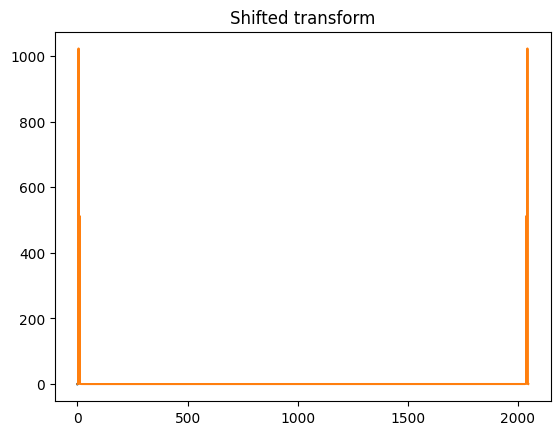

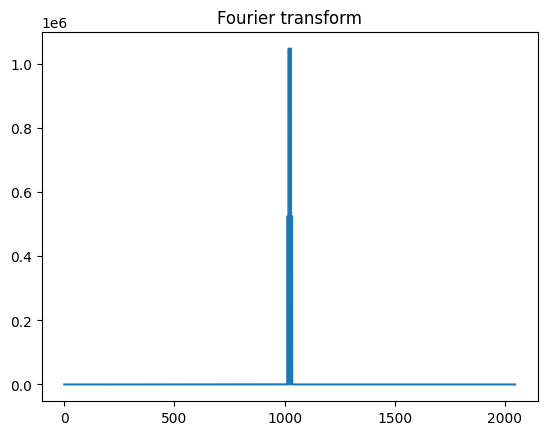

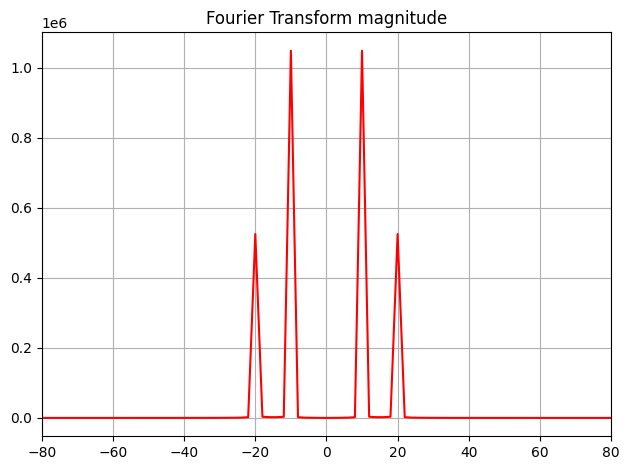

In [14]:

plt.plot(x, s)
S = np.fft.fft(s) # Fourier transform
plt.plot(np.abs(S))
plt.title("Shifted transform")
plt.show()

S = np.fft.fftshift(S) *N/2# Fourier transform shift
plt.plot(np.abs(S))
plt.title("Fourier transform")
plt.show()


freq = np.fft.fftfreq(N, d=dx)        # Fourier transform in frequency domain
freq_centered = np.fft.fftshift(freq)  # Shift fourier frequency

# Plotting


# Frequency domain (magnitude)
plt.plot(freq_centered, np.abs(S), 'r-')
plt.title('Fourier Transform magnitude')
plt.grid(True)
plt.xlim(-80, 80)

plt.tight_layout()
plt.show()

### Example 3 :  A noisy wave example

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import time

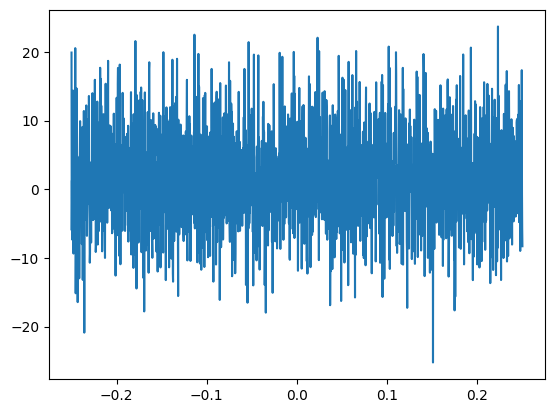

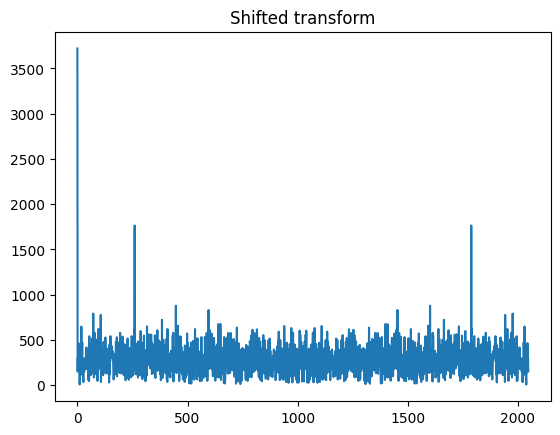

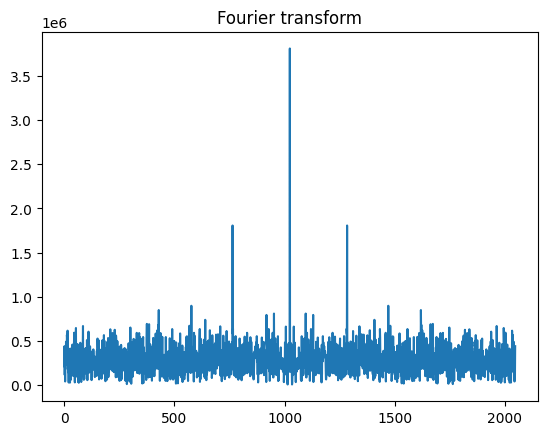

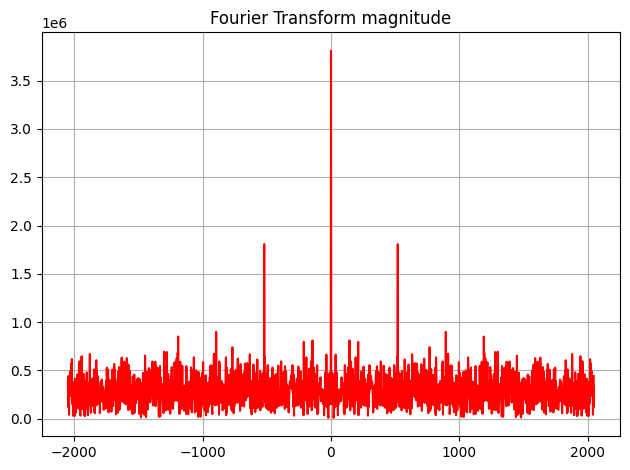

In [16]:
N = 2048
x_min, x_max = -0.25, 0.25
x = np.linspace(x_min,x_max, N)
dx = x[1] - x[0] # delta 
f1 = 1050
f2 = 520
f3 = 851
a1 = 0.5
a2 = 1.5
a3 = 0.3

s = a1*np.cos(2*np.pi*f1*x) + a2*np.cos(2*np.pi*f2*x) + a3*np.cos(2*np.pi*f3*x) + 2 # function
noise = np.random.randn(len(x)) * 7   
s = s + noise
plt.plot(x, s)
plt.show()

S = np.fft.fft(s) # Fourier transform
plt.plot(np.abs(S))
plt.title("Shifted transform")
plt.show()

S = np.fft.fftshift(S) *N/2# Fourier transform shift
plt.plot(np.abs(S))
plt.title("Fourier transform")
plt.show()


freq = np.fft.fftfreq(N, d=dx)        # Fourier transform in frequency domain
freq_centered = np.fft.fftshift(freq)  # Shift fourier frequency

# Plotting


# Frequency domain (magnitude)
plt.plot(freq_centered, np.abs(S), 'r-')
plt.title('Fourier Transform magnitude')
plt.grid(True)


plt.tight_layout()
plt.show()

### Example 4 : Fourier Transform of the Slits (Fraunhofer Diffraction)

##### Fourier Optics: Fraunhofer Diffraction from Apertures

This notebook simulates the far‑field (Fraunhofer) diffraction pattern of three common apertures – square, slit, and circular – using the 2D Fast Fourier Transform (FFT). According to scalar diffraction theory, the diffracted field in the far zone is proportional to the Fourier transform of the aperture transmission function.

##### Theory

For a monochromatic plane wave normally incident on an aperture with transmission function $t(x,y)$, the complex amplitude in the far field (Fraunhofer regime) is  

$$
U(u,v) \propto \iint_{-\infty}^{\infty} t(x,y) \, e^{-i2\pi(ux+vy)} \, dx\,dy
$$

where $u = x'/(\lambda z)$, $v = y'/(\lambda z)$ are spatial frequencies (in cycles per unit length). Thus the intensity pattern is essentially $| \mathcal{F}\{t\}|^2$.

In this code we numerically compute $\mathcal{F}\{t\}$ using `np.fft.fft2`, apply `fftshift` to centre the zero frequency, and plot the logarithm of the magnitude for better visibility.

##### What the code does

1. **Define coordinate grids**  
   $x \in [-1,1]$ (1024 points) and $y \in [-1,1]$ (512 points). A 2D meshgrid is created.

2. **Generate three aperture masks**  
   - **Square**: $|x| < 0.01$ and $|y| < 0.01$ (width 0.02).  
   - **Slit**: $0 < x < 0.01$ and $|y| < 0.8$ (horizontal slit).  
   - **Circular**: $r = \sqrt{x^2+y^2} < 0.03$.  

   All masks are binary: 1 inside the aperture, 0 outside.

3. **Compute the Fourier transform**  
   `np.fft.fft2` performs the 2D DFT. After shifting with `np.fft.fftshift`, the zero frequency is at the centre of the array.  
   Frequency axes (in $\text{m}^{-1}$) are obtained via `np.fft.fftfreq`.

4. **Plot the diffraction patterns**  
   The magnitude $|\mathcal{F}\{t\}|$ is displayed on a logarithmic scale (`np.log(1+|...|)`) to enhance weak features.  
   The three patterns illustrate well‑known results:  
   - Square aperture → 2D sinc function $\text{sinc}(u)\text{sinc}(v)$.  
   - Slit → 1D sinc in $x$‑direction, unchanged in $y$.  
   - Circular aperture → Airy disk $\left(2J_1(\pi r_0 \rho)/(\pi r_0 \rho)\right)^2$, where $\rho = \sqrt{u^2+v^2}$.

##### Why this is helpful

- **Direct application of the convolution theorem** – the FFT replaces Fresnel or Fraunhofer integrals.
- **Fast and flexible** – you can easily change aperture shapes or illumination conditions.
- **Visualisation of classic diffraction patterns** – connecting theory (sinc, Airy) to numerical simulation.
- **Preparation for more advanced topics** – e.g., grating diffraction, Fourier filtering, or optical system modelling.

For any real optical simulation, always use `numpy.fft.fft2` (or `scipy.fft`). The code above provides a complete, ready‑to‑use framework for simulating Fraunhofer diffraction from arbitrary apertures.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import time

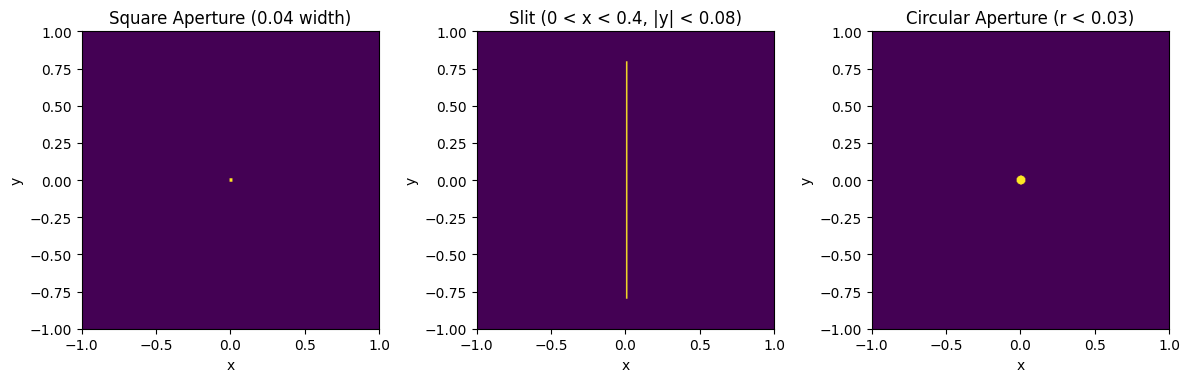

In [31]:
Nx = 1024
Ny = 512
x0 = np.linspace(-1, 1, Nx)
y0 = np.linspace(-1, 1, Ny)
X, Y = np.meshgrid(x0, y0)

#### converting coordinates into polar in case of circular aperture
def car2pol(X, Y):
    r = np.sqrt(X**2 + Y**2)   
    th = np.arctan2(Y, X)    
    return r, th
r, th = car2pol(X,Y)


def square_aperture(X, Y, half_width=0.01):
    condition = (np.abs(X) < half_width) & (np.abs(Y) < half_width)
    return np.where(condition, 1, 0)

def slit(X, Y, width=0.01):
    condition = (0 < X) & (X < width) & (np.abs(Y) < 0.8)
    return np.where(condition, 1, 0)

def circular(r, th):
    condition = r < 0.03
    return np.where(condition, 1, 0)

# --- Generate the apertures ---
square_mask = square_aperture(X, Y)
slit_mask = slit(X, Y)
circular_mask = circular(r, th)

# --- Plotting in a row of subplots ---
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Common imshow parameters
imshow_kw = dict(cmap='viridis', origin='lower', extent=[-1, 1, -1, 1])

# Square aperture
im0 = axes[0].imshow(square_mask, **imshow_kw)
axes[0].set_title('Square Aperture (0.04 width)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

# Slit aperture
im1 = axes[1].imshow(slit_mask, **imshow_kw)
axes[1].set_title('Slit (0 < x < 0.4, |y| < 0.08)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

# Circular aperture
im2 = axes[2].imshow(circular_mask, **imshow_kw)
axes[2].set_title('Circular Aperture (r < 0.03)')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')



plt.tight_layout()
plt.show()

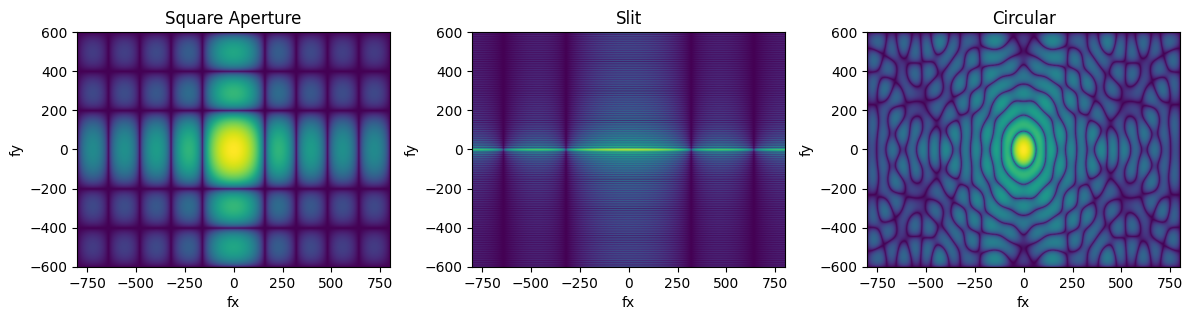

In [46]:
# Fourier transform of the square aperture
square_fft = np.fft.fftshift(np.fft.fft2(square_mask))
# Fourier transform of the single slit
slit_fft = np.fft.fftshift(np.fft.fft2(slit_mask))
# Fourier transform of the circular aperture
circular_fft = np.fft.fftshift(np.fft.fft2(circular_mask))



# Frequency axes (1D)
freq_x = np.fft.fftshift(np.fft.fftfreq(Nx, d=(x0[1]-x0[0])))   
freq_y = np.fft.fftshift(np.fft.fftfreq(Ny, d=(y0[1]-y0[0])))
# 2D frequency grid
FX, FY = np.meshgrid(freq_x, freq_y)

# --- Plotting in a row of subplots ---
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Common imshow parameters
imshow_kw = dict(cmap='viridis', origin='lower', extent=[-1, 1, -1, 1])

# Square aperture
im0 = axes[0].imshow(np.log(1 + np.abs(square_fft)), cmap='viridis', 
           extent=[-800, 800,-600, 600])
axes[0].set_title('Square Aperture')
axes[0].set_xlabel('fx')
axes[0].set_ylabel('fy')

# Slit aperture
im1 = axes[1].imshow(np.log(1 + np.abs(slit_fft)), cmap='viridis', 
           extent=[-800, 800,-600, 600])
axes[1].set_title('Slit')
axes[1].set_xlabel('fx')
axes[1].set_ylabel('fy')

# Circular aperture
im2 = axes[2].imshow(np.log(1 + np.abs(circular_fft)), cmap='viridis', 
           extent=[-800, 800,-600, 600])
axes[2].set_title('Circular')
axes[2].set_xlabel('fx')
axes[2].set_ylabel('fy')



plt.tight_layout()
plt.show()


### Example 5: Fourier Of The Fourier!!

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import time
from PIL import Image

In [58]:
image_path = "Joseph_Fourier.jpg"  # define the path of the image
img = Image.open(image_path).convert('L') # open the image

img_array = np.array(img, dtype=float) # Using numpy and converting image to an array with the float type for better result


In [61]:

S = np.fft.fftshift(np.fft.fft2(img_array))

# Compute frequency
F = np.fft.fftshift(np.fft.fft2(img_array))
log_magnitude = np.log(np.abs(F))

# Create frequency axes 
rows, cols = img_array.shape
fx = np.fft.fftshift(np.fft.fftfreq(cols, d=1))   
fy = np.fft.fftshift(np.fft.fftfreq(rows, d=1))



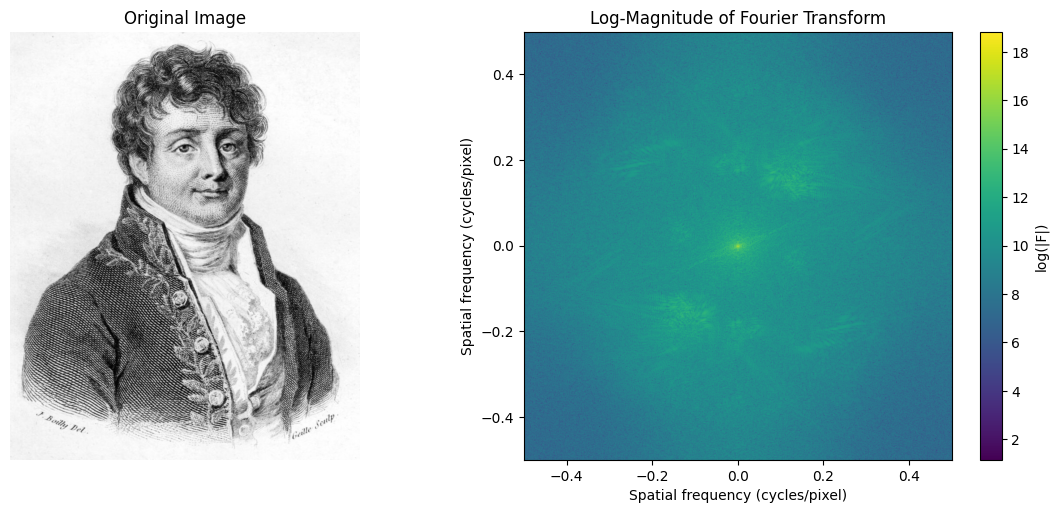

In [62]:
# Plot the original image and its magnitude spectrum
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img_array, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(log_magnitude, cmap='viridis', extent=[fx.min(), fx.max(), fy.min(), fy.max()])
plt.title('Log‑Magnitude of Fourier Transform')
plt.xlabel('Spatial frequency (cycles/pixel)')
plt.ylabel('Spatial frequency (cycles/pixel)')
plt.colorbar(label='log(|F|)')

plt.tight_layout()
plt.show()